In [8]:
import pandas as pd
import numpy as np

# Path relative to the Notebooks/ folder (local repo)
# If on Colab, replace with: "/content/drive/MyDrive/merged_flight_weather.csv"
file_path = "../Data/merged_flight_weather.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 1065161
Columns: 43


,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),...,rain_flag,thunderstorm_flag,freezing_rain_flag,snow_flag,fog_flag,rain_intensity,thunderstorm_intensity,freezing_rain_intensity,snow_intensity,fog_intensity
0,AS,01/01/2016,15.0,N552AS,SEA,18:45,19:10,400.0,373.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AS,01/01/2016,25.0,N492AS,SEA,07:00,07:03,405.0,371.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AS,01/01/2016,33.0,N549AS,PDX,17:10,17:20,399.0,332.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AS,01/01/2016,769.0,N526AS,SAN,18:15,18:12,419.0,370.0,-3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AS,01/01/2017,15.0,N568AS,SEA,18:50,21:40,400.0,384.0,170.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
weather_flags = [
    "rain_flag",
    "snow_flag",
    "fog_flag",
    "thunderstorm_flag",
    "freezing_rain_flag"
]

df[weather_flags] = df[weather_flags].fillna(0)

print("Missing values after fill:")
print(df[weather_flags].isna().sum())

Missing values after fill:
rain_flag             0
snow_flag             0
fog_flag              0
thunderstorm_flag     0
freezing_rain_flag    0
dtype: int64


In [10]:
feature_cols = [
    "Carrier Name",
    "Season",
    "Day_Name",
    "Time_Bucket",
    "Scheduled_Hour",
    "Scheduled elapsed time (Minutes)",
    "rain_flag",
    "snow_flag",
    "fog_flag",
    "thunderstorm_flag",
    "freezing_rain_flag"
]

X = df[feature_cols]
y = df["Delay_20"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (1065161, 11)
y shape: (1065161,)


,Carrier Name,Season,Day_Name,Time_Bucket,Scheduled_Hour,Scheduled elapsed time (Minutes),rain_flag,snow_flag,fog_flag,thunderstorm_flag,freezing_rain_flag
0,Alaska Airlines,Winter,Friday,Evening,18,400.0,0.0,0.0,0.0,0.0,0.0
1,Alaska Airlines,Winter,Friday,Early Morning,7,405.0,0.0,0.0,0.0,0.0,0.0
2,Alaska Airlines,Winter,Friday,Afternoon,17,399.0,0.0,0.0,0.0,0.0,0.0
3,Alaska Airlines,Winter,Friday,Evening,18,419.0,0.0,0.0,0.0,0.0,0.0
4,Alaska Airlines,Winter,Sunday,Evening,18,400.0,0.0,0.0,0.0,0.0,0.0


In [11]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)
X.head()

X shape after encoding: (1065161, 28)


,Scheduled_Hour,Scheduled elapsed time (Minutes),rain_flag,snow_flag,fog_flag,thunderstorm_flag,freezing_rain_flag,Carrier Name_American Airlines,Carrier Name_Delta Air Lines,Carrier Name_Frontier Airlines,...,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday,Time_Bucket_Early Morning,Time_Bucket_Evening,Time_Bucket_Late Night,Time_Bucket_Midday,Time_Bucket_Morning Peak
0,18,400.0,0.0,0.0,0.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,7,405.0,0.0,0.0,0.0,0.0,0.0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,17,399.0,0.0,0.0,0.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,18,419.0,0.0,0.0,0.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,18,400.0,0.0,0.0,0.0,0.0,0.0,False,False,False,...,False,True,False,False,False,False,True,False,False,False


In [12]:
weather_flags = ["rain_flag", "snow_flag", "fog_flag", "thunderstorm_flag", "freezing_rain_flag"]
df[weather_flags] = df[weather_flags].fillna(0)
print(df[weather_flags].isna().sum())

rain_flag             0
snow_flag             0
fog_flag              0
thunderstorm_flag     0
freezing_rain_flag    0
dtype: int64


In [13]:
feature_cols = [
    "Carrier Name", "Season", "Day_Name", "Time_Bucket",
    "Scheduled_Hour", "Scheduled elapsed time (Minutes)",
    "rain_flag", "snow_flag", "fog_flag", "thunderstorm_flag", "freezing_rain_flag"
]

X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df["Delay_20"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1065161, 28)
y shape: (1065161,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (852128, 28) | Test: (213033, 28)


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=50,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Training complete.")


Training complete.


AUC:      0.7004
Accuracy: 0.6310

              precision    recall  f1-score   support

     On-time       0.90      0.62      0.74    176862
     Delayed       0.27      0.67      0.38     36171

    accuracy                           0.63    213033
   macro avg       0.58      0.64      0.56    213033
weighted avg       0.79      0.63      0.68    213033



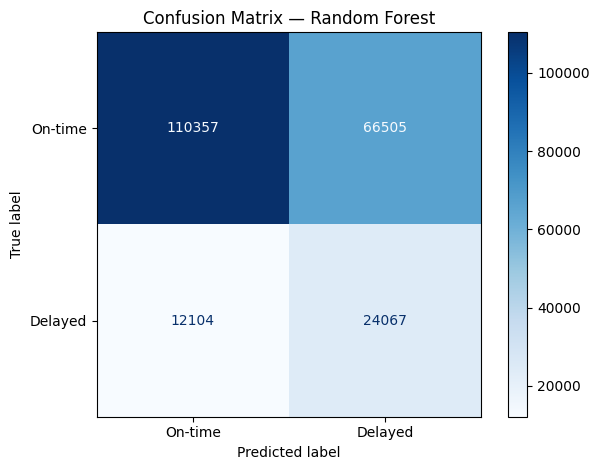

In [22]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

y_proba = rf.predict_proba(X_test)[:, 1]
y_pred  = rf.predict(X_test)

print(f"AUC:      {roc_auc_score(y_test, y_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["On-time", "Delayed"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["On-time", "Delayed"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()


Scheduled_Hour                      0.385250
Time_Bucket_Early Morning           0.181500
Time_Bucket_Evening                 0.122988
fog_flag                            0.058771
Time_Bucket_Morning Peak            0.054766
Season_Summer                       0.035203
Scheduled elapsed time (Minutes)    0.032936
Carrier Name_JetBlue Airways        0.028663
Time_Bucket_Midday                  0.016597
Carrier Name_American Airlines      0.011292
rain_flag                           0.009037
Carrier Name_Spirit Airlines        0.008132
Season_Winter                       0.007325
Carrier Name_Southwest Airlines     0.006951
Carrier Name_United Airlines        0.006282
dtype: float64


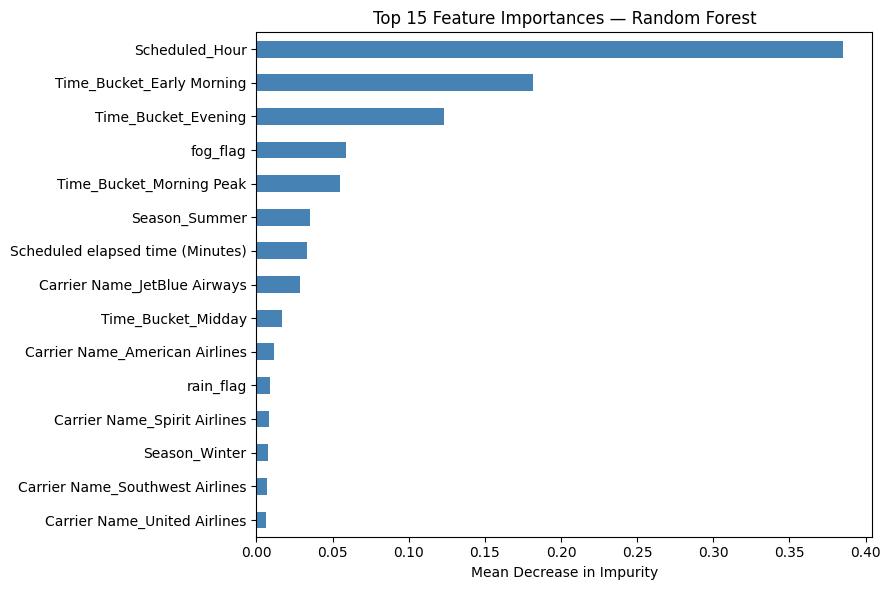

In [23]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(15))

importances.head(15).sort_values().plot(kind="barh", figsize=(9, 6), color="steelblue")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()


In [24]:
# Hyperparameter tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 10, 15],
    "min_samples_leaf": [20, 50, 100],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV AUC:", round(grid_search.best_score_, 4))


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}
Best CV AUC: 0.7093


Tuned AUC:      0.7072  (baseline: 0.7004)
Tuned Accuracy: 0.6472  (baseline: 0.6310)

              precision    recall  f1-score   support

     On-time       0.90      0.65      0.75    176862
     Delayed       0.27      0.66      0.39     36171

    accuracy                           0.65    213033
   macro avg       0.59      0.65      0.57    213033
weighted avg       0.80      0.65      0.69    213033



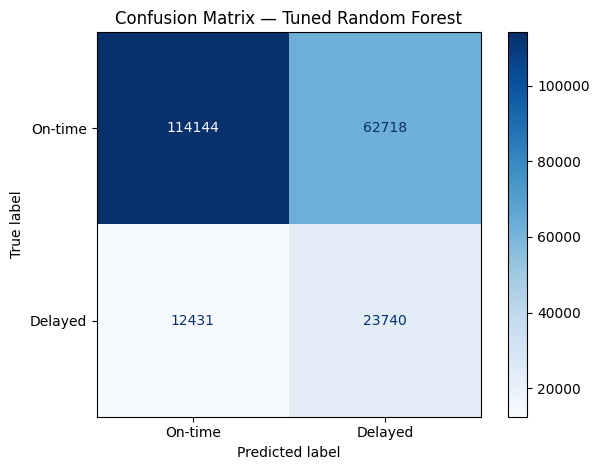

In [26]:
best_rf = grid_search.best_estimator_

y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]
y_pred_tuned  = best_rf.predict(X_test)

print(f"Tuned AUC:      {roc_auc_score(y_test, y_proba_tuned):.4f}  (baseline: 0.7004)")
print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}  (baseline: 0.6310)")
print()
print(classification_report(y_test, y_pred_tuned, target_names=["On-time", "Delayed"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tuned), display_labels=["On-time", "Delayed"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Tuned Random Forest")
plt.tight_layout()
plt.show()


Scheduled_Hour                      0.334578
Time_Bucket_Early Morning           0.152646
Scheduled elapsed time (Minutes)    0.106698
Time_Bucket_Evening                 0.097010
fog_flag                            0.057687
Time_Bucket_Morning Peak            0.044897
Season_Summer                       0.036197
Carrier Name_JetBlue Airways        0.026832
Time_Bucket_Midday                  0.015699
Season_Winter                       0.012516
Carrier Name_American Airlines      0.012316
rain_flag                           0.011670
Carrier Name_Spirit Airlines        0.009422
Carrier Name_Southwest Airlines     0.008779
Carrier Name_United Airlines        0.008128
dtype: float64


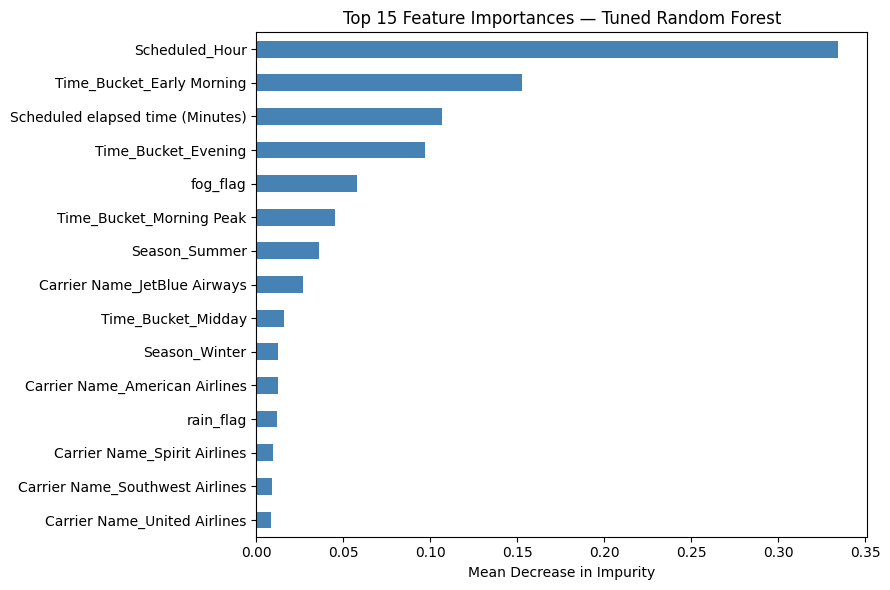

In [27]:
importances_tuned = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importances_tuned.head(15))

importances_tuned.head(15).sort_values().plot(kind="barh", figsize=(9, 6), color="steelblue")
plt.title("Top 15 Feature Importances — Tuned Random Forest")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()


In [28]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[["param_n_estimators", "param_max_depth", "param_min_samples_leaf", 
                    "param_max_features", "mean_test_score", "rank_test_score"]]
results = results.sort_values("rank_test_score")
print(results.head(10))


    param_n_estimators  param_max_depth  param_min_samples_leaf  \
25                 300               15                      20   
24                 200               15                      20   
27                 300               15                      50   
26                 200               15                      50   
31                 300               15                      20   
30                 200               15                      20   
29                 300               15                     100   
33                 300               15                      50   
28                 200               15                     100   
32                 200               15                      50   

   param_max_features  mean_test_score  rank_test_score  
25               sqrt         0.709288                1  
24               sqrt         0.709260                2  
27               sqrt         0.708458                3  
26               sqrt         